# Неделя 6 — расширение safety-oriented RUL pipeline

## 1. Идея недели

На пятой неделе лучший результат был получен через квантильное уточнение прогноза RandomForest. Вместо одного среднего прогноза использовалась смесь осторожного нижнего квантиля и среднего прогноза:

prediction = 0.6 * q35 + 0.4 * mean - 1.0

Это позволило снизить MAE примерно до 8.92. Однако дальнейший ручной подбор параметров на official test может привести к подгонке под тестовую выборку. Поэтому на этой неделе мы проверяем новые идеи более аккуратно.

Мы рассматриваем три направления:

1. Официальная асимметричная RUL-метрика. MAE одинаково штрафует завышение и занижение, однако в задаче остаточного ресурса завышение опаснее. Поэтому дополнительно считаем score, который сильнее штрафует overestimation.

2. Out-of-fold residual calibration. Вместо фиксированной ручной поправки обучаем небольшую correction-модель на out-of-fold прогнозах внутри train-выборки. Она должна научиться исправлять систематические ошибки базового прогноза, не используя official test для обучения.

3. Degradation-onset features. Мы добавляем признаки, описывающие отклонение двигателя от собственного начального состояния и начало устойчивой деградации двигателя.

## 2. Imports and configuration

In [1]:
import hashlib
import json
import os
import random
import time
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import Markdown, display
from sklearn.ensemble import GradientBoostingRegressor, RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import GroupKFold, train_test_split

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
random.seed(RANDOM_STATE)

DATA_DIR = Path("CMAPSSData")

BASELINE_CAP = 140
BASELINE_Q = 0.35
BASELINE_Q_WEIGHT = 0.6
BASELINE_MEAN_WEIGHT = 0.4
BASELINE_SHIFT = 1.0

N_FOLDS = 5

residual_shift_grid = np.arange(0, 3.5, 0.5)
correction_clip_grid = [5, 10, 15, 20]
validation_target_ruls = [10, 20, 30, 50, 70, 90, 110, 130]
onset_threshold_grid = [2, 3, 4]
combined_shift_grid = [0, 0.5, 1.0, 1.5]

final_rf_base = {"n_estimators": 400, "random_state": RANDOM_STATE, "n_jobs": -1}

columns = [
    "unit_id",
    "cycle",
    "op_setting_1",
    "op_setting_2",
    "op_setting_3",
    "sensor_1",
    "sensor_2",
    "sensor_3",
    "sensor_4",
    "sensor_5",
    "sensor_6",
    "sensor_7",
    "sensor_8",
    "sensor_9",
    "sensor_10",
    "sensor_11",
    "sensor_12",
    "sensor_13",
    "sensor_14",
    "sensor_15",
    "sensor_16",
    "sensor_17",
    "sensor_18",
    "sensor_19",
    "sensor_20",
    "sensor_21",
]

target_col = "Remaining Useful Life"
eps = 1e-6
pd.set_option("display.max_columns", 120)
pd.set_option("display.width", 180)

In [2]:
def none_if_missing(value):
    if value is None:
        return None
    if isinstance(value, str) and value in {"None", "nan", "NaN", ""}:
        return None
    try:
        if pd.isna(value):
            return None
    except TypeError:
        pass
    return value


def parse_rf_max_features(value):
    value = none_if_missing(value)
    if value is None:
        return None
    if isinstance(value, str):
        if value in {"sqrt", "log2"}:
            return value
        try:
            return float(value)
        except ValueError:
            return value
    return value


best_week4_candidate = {
    "selected_blocks": [
        "delta",
        "edge_means",
        "first",
        "last_minus_mean",
        "max",
        "mean",
        "median",
        "min",
        "range",
        "slope",
        "slope_change",
        "std",
        "tail_quantiles",
        "volatility",
    ],
    "window_size": 40,
    "rul_cap": 125,
    "rf_max_depth": 24,
    "rf_min_samples_leaf": 3,
    "rf_min_samples_split": 2,
    "rf_max_features": 0.4,
}
old_week4_shift = 2.0
pd.DataFrame(
    [
        {
            **best_week4_candidate,
            "baseline_cap": BASELINE_CAP,
            "baseline_shift": BASELINE_SHIFT,
        }
    ]
)

,selected_blocks,window_size,rul_cap,rf_max_depth,rf_min_samples_leaf,rf_min_samples_split,rf_max_features,baseline_cap,baseline_shift
0,"[delta, edge_means, first, last_minus_mean, ma...",40,125,24,3,2,0.4,140,1.0


## 3. Загрузка данных

Используем FD001. Для train считаем RUL как разницу между последним циклом двигателя и текущим циклом. Для official test берём последние доступные данные каждого двигателя и true RUL из `RUL_FD001.txt`.

In [3]:
def load_cmapss_fd001(data_dir):
    train_df = pd.read_table(
        data_dir / "train_FD001.txt", sep=r"\s+", header=None, names=columns
    )
    test_df = pd.read_table(
        data_dir / "test_FD001.txt", sep=r"\s+", header=None, names=columns
    )
    rul_test_df = pd.read_table(
        data_dir / "RUL_FD001.txt", sep=r"\s+", header=None, names=["RUL"]
    )
    return train_df, test_df, rul_test_df


def add_rul_target(train_df):
    train_df = train_df.copy()
    max_cycle = train_df.groupby("unit_id")["cycle"].max()
    train_df[target_col] = train_df["unit_id"].map(max_cycle) - train_df["cycle"]
    return train_df


train_df, test_df, rul_test_df = load_cmapss_fd001(DATA_DIR)
train_df = add_rul_target(train_df)
y_test_official = rul_test_df["RUL"].reset_index(drop=True)
feature_source_cols = [
    col
    for col in train_df.columns
    if col.startswith("op_setting_") or col.startswith("sensor_")
]

pd.DataFrame(
    {
        "dataset": ["train", "test", "official_rul"],
        "rows": [len(train_df), len(test_df), len(rul_test_df)],
        "units": [
            train_df["unit_id"].nunique(),
            test_df["unit_id"].nunique(),
            len(rul_test_df),
        ],
    }
)

,dataset,rows,units
0,train,20631,100
1,test,13096,100
2,official_rul,100,100


In [4]:
sensor_cols = [col for col in train_df.columns if col.startswith("sensor_")]
sensor_corr = (
    train_df[sensor_cols + [target_col]]
    .corr(numeric_only=True)[target_col]
    .drop(target_col)
    .abs()
    .sort_values(ascending=False)
)
active_sensor_cols = sensor_corr.head(10).index.tolist()
pd.DataFrame(
    {
        "active_sensor": active_sensor_cols,
        "abs_corr_with_RUL": sensor_corr.loc[active_sensor_cols].values,
    }
)

,active_sensor,abs_corr_with_RUL
0,sensor_11,0.696228
1,sensor_4,0.678948
2,sensor_12,0.671983
3,sensor_7,0.657223
4,sensor_15,0.642667
5,sensor_21,0.635662
6,sensor_20,0.629428
7,sensor_2,0.606484
8,sensor_17,0.606154
9,sensor_3,0.584520


## 4. Воспроизведение лучшего Week 5 baseline

Используем тот же aggregated RandomForest pipeline, cap=140 и финальную формулу:

prediction = 0.6 * q35 + 0.4 * mean - 1.0

In [5]:
all_feature_blocks = [
    "mean",
    "std",
    "min",
    "max",
    "range",
    "delta",
    "slope",
    "last_minus_mean",
    "median",
    "iqr",
    "first",
    "last",
    "relative_delta",
    "relative_last_minus_mean",
    "rms",
    "edge_means",
    "slope_change",
    "tail_quantiles",
    "robust_spread",
    "volatility",
]


def calculate_slope(values):
    values = np.asarray(values, dtype=float)
    if len(values) <= 1:
        return 0.0
    x = np.arange(len(values), dtype=float)
    x = x - x.mean()
    denominator = np.sum(x**2)
    if denominator == 0:
        return 0.0
    return float(np.dot(values, x) / denominator)


def calculate_rms(values):
    values = np.asarray(values, dtype=float)
    return float(np.sqrt(np.mean(values**2))) if len(values) else 0.0


def calculate_slope_change(values):
    values = np.asarray(values, dtype=float)
    split_index = len(values) // 2
    if split_index == 0 or split_index == len(values):
        return 0.0
    return calculate_slope(values[split_index:]) - calculate_slope(values[:split_index])


def calculate_volatility(values):
    values = np.asarray(values, dtype=float)
    if len(values) <= 1:
        return 0.0
    return float(np.mean(np.abs(np.diff(values))))


def feature_name(source_col, block, suffix, window_size):
    return f"{source_col}_{block}_{suffix}_{window_size}"


def expected_feature_columns(config):
    suffixes_by_block = {
        "edge_means": ["first_edge", "last_edge"],
        "tail_quantiles": ["q10", "q90"],
    }
    result = []
    for block_name in config["selected_blocks"]:
        for suffix in suffixes_by_block.get(block_name, ["value"]):
            for source_col in feature_source_cols:
                result.append(
                    feature_name(source_col, block_name, suffix, config["window_size"])
                )
    return result


def make_block_frame(block_name, block_values, window_size):
    if isinstance(block_values, dict):
        frames = []
        for suffix, values in block_values.items():
            frame = values.copy()
            frame.columns = [
                feature_name(col, block_name, suffix, window_size)
                for col in frame.columns
            ]
            frames.append(frame)
        return pd.concat(frames, axis=1)
    frame = block_values.copy()
    frame.columns = [
        feature_name(col, block_name, "value", window_size) for col in frame.columns
    ]
    return frame


def build_rolling_feature_blocks(sorted_df, config, require_full_window):
    window_size = config["window_size"]
    edge_window_size = max(1, min(10, window_size // 3))
    min_periods = window_size if require_full_window else 1
    edge_min_periods = edge_window_size if require_full_window else 1
    rolling = sorted_df.groupby("unit_id")[feature_source_cols].rolling(
        window=window_size, min_periods=min_periods
    )
    edge_rolling = sorted_df.groupby("unit_id")[feature_source_cols].rolling(
        window=edge_window_size, min_periods=edge_min_periods
    )
    mean_features = rolling.mean().reset_index(level=0, drop=True)
    std_features = rolling.std(ddof=0).reset_index(level=0, drop=True).fillna(0)
    min_features = rolling.min().reset_index(level=0, drop=True)
    max_features = rolling.max().reset_index(level=0, drop=True)
    median_features = rolling.median().reset_index(level=0, drop=True)
    q10_features = rolling.quantile(0.10).reset_index(level=0, drop=True)
    q25_features = rolling.quantile(0.25).reset_index(level=0, drop=True)
    q75_features = rolling.quantile(0.75).reset_index(level=0, drop=True)
    q90_features = rolling.quantile(0.90).reset_index(level=0, drop=True)
    first_features = sorted_df.groupby("unit_id")[feature_source_cols].shift(
        window_size - 1
    )
    if not require_full_window:
        first_features = first_features.fillna(
            sorted_df.groupby("unit_id")[feature_source_cols].transform("first")
        )
    last_features = sorted_df[feature_source_cols]
    delta_features = last_features - first_features
    last_minus_mean_features = last_features - mean_features
    block_values = {
        "mean": mean_features,
        "std": std_features,
        "min": min_features,
        "max": max_features,
        "range": max_features - min_features,
        "delta": delta_features,
        "slope": rolling.apply(calculate_slope, raw=True).reset_index(
            level=0, drop=True
        ),
        "last_minus_mean": last_minus_mean_features,
        "median": median_features,
        "iqr": q75_features - q25_features,
        "first": first_features,
        "last": last_features,
        "relative_delta": delta_features / (first_features.abs() + eps),
        "relative_last_minus_mean": last_minus_mean_features
        / (mean_features.abs() + eps),
        "rms": rolling.apply(calculate_rms, raw=True).reset_index(level=0, drop=True),
        "edge_means": {
            "first_edge": rolling.apply(
                lambda values: np.mean(values[:edge_window_size]), raw=True
            ).reset_index(level=0, drop=True),
            "last_edge": edge_rolling.mean().reset_index(level=0, drop=True),
        },
        "slope_change": rolling.apply(calculate_slope_change, raw=True).reset_index(
            level=0, drop=True
        ),
        "tail_quantiles": {"q10": q10_features, "q90": q90_features},
        "robust_spread": q90_features - q10_features,
        "volatility": rolling.apply(calculate_volatility, raw=True).reset_index(
            level=0, drop=True
        ),
    }
    return pd.concat(
        [
            make_block_frame(block, block_values[block], window_size)
            for block in config["selected_blocks"]
        ],
        axis=1,
    )

In [6]:
def single_history_feature_row(history_df, config):
    window_size = config["window_size"]
    edge_window_size = max(1, min(10, window_size // 3))
    window_df = history_df.sort_values("cycle").tail(window_size)
    if len(window_df) == 0:
        raise ValueError("Пустая история cutoff")
    row = {}
    for col in feature_source_cols:
        values = window_df[col].to_numpy(dtype=float)
        first_value = float(values[0])
        last_value = float(values[-1])
        mean_value = float(np.mean(values))
        min_value = float(np.min(values))
        max_value = float(np.max(values))
        q10_value = float(np.quantile(values, 0.10))
        q25_value = float(np.quantile(values, 0.25))
        q75_value = float(np.quantile(values, 0.75))
        q90_value = float(np.quantile(values, 0.90))
        values_by_block = {
            "mean": [("value", mean_value)],
            "std": [("value", float(np.std(values)))],
            "min": [("value", min_value)],
            "max": [("value", max_value)],
            "range": [("value", max_value - min_value)],
            "delta": [("value", last_value - first_value)],
            "slope": [("value", calculate_slope(values))],
            "last_minus_mean": [("value", last_value - mean_value)],
            "median": [("value", float(np.median(values)))],
            "iqr": [("value", q75_value - q25_value)],
            "first": [("value", first_value)],
            "last": [("value", last_value)],
            "relative_delta": [
                ("value", (last_value - first_value) / (abs(first_value) + eps))
            ],
            "relative_last_minus_mean": [
                ("value", (last_value - mean_value) / (abs(mean_value) + eps))
            ],
            "rms": [("value", calculate_rms(values))],
            "edge_means": [
                ("first_edge", float(np.mean(values[:edge_window_size]))),
                ("last_edge", float(np.mean(values[-edge_window_size:]))),
            ],
            "slope_change": [("value", calculate_slope_change(values))],
            "tail_quantiles": [("q10", q10_value), ("q90", q90_value)],
            "robust_spread": [("value", q90_value - q10_value)],
            "volatility": [("value", calculate_volatility(values))],
        }
        for block_name in config["selected_blocks"]:
            for suffix, value in values_by_block[block_name]:
                row[feature_name(col, block_name, suffix, window_size)] = value
    return row


def build_aggregated_features_for_units(
    df, config, mode, validation_cutoffs=None, cap_target=True
):
    expected_columns = expected_feature_columns(config)
    if mode == "train":
        sorted_df = df.sort_values(["unit_id", "cycle"]).reset_index(drop=True)
        feature_frame = build_rolling_feature_blocks(
            sorted_df, config, require_full_window=True
        )
        result_df = pd.concat(
            [sorted_df[["unit_id", "cycle", target_col]], feature_frame], axis=1
        )
        result_df = (
            result_df[result_df["cycle"] >= config["window_size"]]
            .dropna()
            .reset_index(drop=True)
        )
        X = result_df[expected_columns]
        y = result_df[target_col].reset_index(drop=True)
        if cap_target and config["rul_cap"] is not None:
            y = y.clip(upper=config["rul_cap"])
        return X, y
    if mode == "official_test":
        sorted_df = df.sort_values(["unit_id", "cycle"]).reset_index(drop=True)
        feature_frame = build_rolling_feature_blocks(
            sorted_df, config, require_full_window=False
        )
        result_df = (
            pd.concat([sorted_df[["unit_id", "cycle"]], feature_frame], axis=1)
            .dropna()
            .reset_index(drop=True)
        )
        last_rows = (
            result_df.sort_values(["unit_id", "cycle"])
            .groupby("unit_id")
            .tail(1)
            .sort_values("unit_id")
            .reset_index(drop=True)
        )
        return last_rows[expected_columns], last_rows["unit_id"].reset_index(drop=True)
    if mode == "validation_cutoff":
        grouped = {
            unit_id: unit_df.sort_values("cycle")
            for unit_id, unit_df in df.groupby("unit_id")
        }
        rows = []
        y_values = []
        ids = []
        for validation_row in validation_cutoffs.itertuples(index=False):
            history_df = grouped[validation_row.unit_id]
            history_df = history_df[history_df["cycle"] <= validation_row.cutoff_cycle]
            rows.append(single_history_feature_row(history_df, config))
            y_values.append(validation_row.true_rul)
            ids.append(f"{validation_row.unit_id}_{validation_row.cutoff_cycle}")
        X = pd.DataFrame(rows).reindex(columns=expected_columns)
        if X.isna().any().any():
            raise ValueError("Validation-признаки содержат NaN")
        return X, pd.Series(y_values), pd.Series(ids)
    raise ValueError(f"Unknown mode: {mode}")

In [7]:
def build_rf_params(candidate, base):
    params = base.copy()
    params.update(
        {
            "max_depth": candidate["rf_max_depth"],
            "min_samples_leaf": candidate["rf_min_samples_leaf"],
            "min_samples_split": candidate["rf_min_samples_split"],
            "max_features": candidate["rf_max_features"],
        }
    )
    return params


def build_error_table(y_true, y_pred, model_name, ids=None):
    ids = np.arange(len(y_true)) if ids is None else ids
    error_df = pd.DataFrame(
        {
            "model_name": model_name,
            "id": ids,
            "true_rul": np.asarray(y_true),
            "pred_rul": np.asarray(y_pred),
        }
    )
    error_df["error"] = error_df["pred_rul"] - error_df["true_rul"]
    error_df["abs_error"] = error_df["error"].abs()
    return error_df


def zone_subset(error_df, zone):
    if zone == "near_failure":
        return error_df[error_df["true_rul"] <= 30]
    if zone == "warning_zone":
        return error_df[(error_df["true_rul"] > 30) & (error_df["true_rul"] <= 70)]
    return error_df


def compute_week4_fitness(metrics):
    near_mae = (
        metrics["near_failure_MAE"]
        if not pd.isna(metrics["near_failure_MAE"])
        else metrics["MAE"]
    )
    warning_mae = (
        metrics["warning_zone_MAE"]
        if not pd.isna(metrics["warning_zone_MAE"])
        else metrics["MAE"]
    )
    return (
        metrics["MAE"]
        + 4.0 * metrics["overestimation_share"]
        + 0.08 * near_mae
        + 0.04 * warning_mae
        + 0.03 * metrics["max_overestimation"]
    )


def metrics_from_error(error_df):
    over = error_df.loc[error_df["error"] > 0, "error"]
    near = zone_subset(error_df, "near_failure")
    warning = zone_subset(error_df, "warning_zone")
    metrics = {
        "MAE": mean_absolute_error(error_df["true_rul"], error_df["pred_rul"]),
        "RMSE": mean_squared_error(error_df["true_rul"], error_df["pred_rul"]) ** 0.5,
        "R2": r2_score(error_df["true_rul"], error_df["pred_rul"]),
        "mean_error": float(error_df["error"].mean()),
        "overestimation_share": float((error_df["error"] > 0).mean()),
        "max_overestimation": float(over.max()) if len(over) else 0.0,
        "near_failure_MAE": (
            mean_absolute_error(near["true_rul"], near["pred_rul"])
            if len(near)
            else np.nan
        ),
        "warning_zone_MAE": (
            mean_absolute_error(warning["true_rul"], warning["pred_rul"])
            if len(warning)
            else np.nan
        ),
    }
    metrics["fitness"] = compute_week4_fitness(metrics)
    return metrics


def metrics_row(model_name, prediction_type, y_true, y_pred, ids=None, extra=None):
    error_df = build_error_table(y_true, y_pred, model_name, ids)
    row = {
        "model_name": model_name,
        "prediction_type": prediction_type,
        **metrics_from_error(error_df),
    }
    if extra:
        row.update(extra)
    return row, error_df


def safety_summary(error_df):
    return pd.DataFrame(
        {
            "zone": ["near_failure", "warning_zone", "all"],
            "count": [
                len(zone_subset(error_df, "near_failure")),
                len(zone_subset(error_df, "warning_zone")),
                len(error_df),
            ],
            "MAE": [
                (
                    metrics_from_error(zone_subset(error_df, "near_failure"))["MAE"]
                    if len(zone_subset(error_df, "near_failure"))
                    else np.nan
                ),
                (
                    metrics_from_error(zone_subset(error_df, "warning_zone"))["MAE"]
                    if len(zone_subset(error_df, "warning_zone"))
                    else np.nan
                ),
                metrics_from_error(error_df)["MAE"],
            ],
            "overestimation_share": [
                (
                    float((zone_subset(error_df, "near_failure")["error"] > 0).mean())
                    if len(zone_subset(error_df, "near_failure"))
                    else np.nan
                ),
                (
                    float((zone_subset(error_df, "warning_zone")["error"] > 0).mean())
                    if len(zone_subset(error_df, "warning_zone"))
                    else np.nan
                ),
                float((error_df["error"] > 0).mean()),
            ],
        }
    )


def rul_zone_analysis(error_df):
    bins = [-1, 30, 70, 125, np.inf]
    labels = ["0-30", "31-70", "71-125", "126+"]
    zoned = error_df.copy()
    zoned["rul_zone"] = pd.cut(zoned["true_rul"], bins=bins, labels=labels)
    rows = []
    for zone, group in zoned.groupby("rul_zone", observed=False):
        if len(group):
            rows.append(
                {
                    "rul_zone": str(zone),
                    "count": len(group),
                    **metrics_from_error(group),
                }
            )
    return pd.DataFrame(rows)

In [8]:
def asymmetric_rul_score(y_true, y_pred):
    errors = np.asarray(y_pred) - np.asarray(y_true)
    scores = np.where(
        errors < 0, np.exp(-errors / 13.0) - 1.0, np.exp(errors / 10.0) - 1.0
    )
    return float(np.sum(scores))


def asymmetric_score_parts(y_true, y_pred):
    errors = np.asarray(y_pred) - np.asarray(y_true)
    scores = np.where(
        errors < 0, np.exp(-errors / 13.0) - 1.0, np.exp(errors / 10.0) - 1.0
    )
    over_mask = errors >= 0
    under_mask = errors < 0
    return {
        "asymmetric_RUL_score": float(np.sum(scores)),
        "mean_asymmetric_score": float(np.mean(scores)),
        "overestimation_component": (
            float(np.sum(scores[over_mask])) if np.any(over_mask) else 0.0
        ),
        "underestimation_component": (
            float(np.sum(scores[under_mask])) if np.any(under_mask) else 0.0
        ),
    }


def zone_subset_extended(error_df, zone):
    if zone == "near_failure":
        return error_df[error_df["true_rul"] <= 30]
    if zone == "warning_zone":
        return error_df[(error_df["true_rul"] > 30) & (error_df["true_rul"] <= 70)]
    if zone == "mid_life":
        return error_df[(error_df["true_rul"] > 70) & (error_df["true_rul"] <= 120)]
    if zone == "long_rul":
        return error_df[error_df["true_rul"] > 120]
    return error_df


def metrics_from_error_extended(error_df):
    over = error_df.loc[error_df["error"] > 0, "error"]
    near = zone_subset_extended(error_df, "near_failure")
    warning = zone_subset_extended(error_df, "warning_zone")
    metrics = {
        "MAE": mean_absolute_error(error_df["true_rul"], error_df["pred_rul"]),
        "RMSE": mean_squared_error(error_df["true_rul"], error_df["pred_rul"]) ** 0.5,
        "R2": r2_score(error_df["true_rul"], error_df["pred_rul"]),
        "mean_error": float(error_df["error"].mean()),
        "overestimation_count": int((error_df["error"] > 0).sum()),
        "overestimation_share": float((error_df["error"] > 0).mean()),
        "mean_overestimation": float(over.mean()) if len(over) else 0.0,
        "max_overestimation": float(over.max()) if len(over) else 0.0,
        "near_failure_MAE": (
            mean_absolute_error(near["true_rul"], near["pred_rul"])
            if len(near)
            else np.nan
        ),
        "warning_zone_MAE": (
            mean_absolute_error(warning["true_rul"], warning["pred_rul"])
            if len(warning)
            else np.nan
        ),
    }
    metrics.update(asymmetric_score_parts(error_df["true_rul"], error_df["pred_rul"]))
    return metrics


def evaluate_prediction(
    method,
    y_true,
    y_pred,
    ids=None,
    description="",
    feature_count=np.nan,
    shift=np.nan,
    extra=None,
):
    row = {
        "method": method,
        "description": description,
        "feature_count": feature_count,
        "shift": shift,
    }
    row.update(
        metrics_from_error_extended(build_error_table(y_true, y_pred, method, ids))
    )
    if extra:
        row.update(extra)
    return row


def tree_prediction_summary(tree_predictions):
    mean_prediction = tree_predictions.mean(axis=0)
    q20 = np.quantile(tree_predictions, 0.20, axis=0)
    q35 = np.quantile(tree_predictions, BASELINE_Q, axis=0)
    q50 = np.quantile(tree_predictions, 0.50, axis=0)
    q80 = np.quantile(tree_predictions, 0.80, axis=0)
    tree_std = tree_predictions.std(axis=0)
    tree_iqr = q80 - q20
    baseline_prediction = np.maximum(
        BASELINE_Q_WEIGHT * q35
        + BASELINE_MEAN_WEIGHT * mean_prediction
        - BASELINE_SHIFT,
        0,
    )
    return pd.DataFrame(
        {
            "baseline_prediction": baseline_prediction,
            "mean_prediction": mean_prediction,
            "q20": q20,
            "q35": q35,
            "q50": q50,
            "q80": q80,
            "tree_std": tree_std,
            "tree_iqr": tree_iqr,
            "mean_minus_q35": mean_prediction - q35,
            "q80_minus_q35": q80 - q35,
            "q35_minus_q20": q35 - q20,
            "predicted_near_flag": (baseline_prediction <= 30).astype(int),
            "predicted_warning_flag": (
                (baseline_prediction > 30) & (baseline_prediction <= 70)
            ).astype(int),
            "predicted_long_flag": (baseline_prediction > 120).astype(int),
        }
    )


def train_rf_model_for_features(X_train, y_train, candidate):
    model = RandomForestRegressor(**build_rf_params(candidate, final_rf_base))
    model.fit(X_train, y_train)
    return model

In [9]:
baseline_candidate = best_week4_candidate.copy()
baseline_candidate["rul_cap"] = BASELINE_CAP
X_train_baseline, y_train_baseline_raw = build_aggregated_features_for_units(
    train_df, baseline_candidate, "train", cap_target=False
)
X_test_baseline, official_unit_ids = build_aggregated_features_for_units(
    test_df, baseline_candidate, "official_test"
)
y_train_baseline = y_train_baseline_raw.clip(upper=BASELINE_CAP)

baseline_model = train_rf_model_for_features(
    X_train_baseline, y_train_baseline, baseline_candidate
)
baseline_tree_predictions = np.array(
    [tree.predict(X_test_baseline) for tree in baseline_model.estimators_]
)
baseline_summary = tree_prediction_summary(baseline_tree_predictions)
pred_baseline = baseline_summary["baseline_prediction"].to_numpy()
baseline_error_df = build_error_table(
    y_test_official, pred_baseline, "Week 5 baseline", official_unit_ids
)
baseline_metrics = metrics_from_error_extended(baseline_error_df)

baseline_table_df = pd.DataFrame(
    [
        {
            "method": "Week 5 baseline",
            "cap": BASELINE_CAP,
            "prediction": "0.6*q35 + 0.4*mean - 1.0",
            **baseline_metrics,
        }
    ]
)
baseline_table_df[
    [
        "method",
        "cap",
        "prediction",
        "MAE",
        "RMSE",
        "R2",
        "mean_error",
        "overestimation_count",
        "overestimation_share",
        "mean_overestimation",
        "max_overestimation",
        "near_failure_MAE",
        "warning_zone_MAE",
    ]
]

/Users/lev/Library/Python/3.9/lib/python/site-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but DecisionTreeRegressor was fitted without feature names
  warnings.warn(
/Users/lev/Library/Python/3.9/lib/python/site-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but DecisionTreeRegressor was fitted without feature names
  warnings.warn(
/Users/lev/Library/Python/3.9/lib/python/site-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but DecisionTreeRegressor was fitted without feature names
  warnings.warn(
/Users/lev/Library/Python/3.9/lib/python/site-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but DecisionTreeRegressor was fitted without feature names
  warnings.warn(
/Users/lev/Library/Python/3.9/lib/python/site-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but DecisionTreeRegressor was fitted without feature names
  warnings.warn(
/User

,method,cap,prediction,MAE,RMSE,R2,mean_error,overestimation_count,overestimation_share,mean_overestimation,max_overestimation,near_failure_MAE,warning_zone_MAE
0,Week 5 baseline,140,0.6*q35 + 0.4*mean - 1.0,8.922427,12.761892,0.905687,-1.333776,47,0.47,8.073032,35.036503,2.381176,6.127128


## 5. Официальная асимметричная RUL-метрика

MAE симметрична: ошибка +20 и ошибка -20 имеют одинаковый вклад. Но для RUL-прогнозирования это не одинаковые ситуации. Если модель завышает остаточный ресурс, двигатель могут оставить в эксплуатации слишком долго. Поэтому дополнительно используется асимметричная метрика, в которой overestimation штрафуется сильнее underestimation.

In [10]:
baseline_asymmetric_df = pd.DataFrame(
    [
        {
            "method": "Week 5 baseline",
            **asymmetric_score_parts(y_test_official, pred_baseline),
        }
    ]
)
baseline_asymmetric_df

,method,asymmetric_RUL_score,mean_asymmetric_score,overestimation_component,underestimation_component
0,Week 5 baseline,231.970144,2.319701,119.840805,112.129339


## 6. Подход A: out-of-fold residual calibration

На предыдущих неделях мы использовали fixed shift и quantile correction. Они корректируют прогноз по заранее заданному правилу. Теперь мы проверяем обучаемую correction-модель. Она получает базовый прогноз и характеристики его неопределённости и учится предсказывать остаточную ошибку:

residual = true_rul - base_prediction

Correction-модель строится на out-of-fold прогнозах внутри train_FD001.

In [11]:
def make_target_rul_cutoffs(valid_df, target_ruls, window_size):
    rows = []
    for unit_id, unit_df in valid_df.groupby("unit_id"):
        max_cycle = int(unit_df["cycle"].max())
        for target_rul in target_ruls:
            cutoff_cycle = max_cycle - int(target_rul)
            if cutoff_cycle > 0 and cutoff_cycle >= window_size:
                rows.append(
                    {
                        "unit_id": unit_id,
                        "cutoff_cycle": cutoff_cycle,
                        "true_rul": int(target_rul),
                    }
                )
    return (
        pd.DataFrame(rows)
        .drop_duplicates(["unit_id", "cutoff_cycle"])
        .reset_index(drop=True)
    )


def calibration_features_from_summary(summary_df):
    columns = [
        "baseline_prediction",
        "mean_prediction",
        "q20",
        "q35",
        "q50",
        "q80",
        "tree_std",
        "tree_iqr",
        "mean_minus_q35",
        "q80_minus_q35",
        "q35_minus_q20",
        "predicted_near_flag",
        "predicted_warning_flag",
        "predicted_long_flag",
    ]
    return summary_df[columns].reset_index(drop=True)


def build_oof_calibration_dataset(onset_variant="none", threshold_sensor_count=3):
    unit_ids = np.array(sorted(train_df["unit_id"].unique()))
    groups = unit_ids.copy()
    fold_rows = []
    group_kfold = GroupKFold(n_splits=N_FOLDS)
    for fold_id, (train_unit_idx, valid_unit_idx) in enumerate(
        group_kfold.split(unit_ids, groups=groups), start=1
    ):
        fold_train_units = set(unit_ids[train_unit_idx])
        fold_valid_units = set(unit_ids[valid_unit_idx])
        fold_train_df = train_df[train_df["unit_id"].isin(fold_train_units)].copy()
        fold_valid_df = train_df[train_df["unit_id"].isin(fold_valid_units)].copy()
        fold_cutoffs_df = make_target_rul_cutoffs(
            fold_valid_df, validation_target_ruls, baseline_candidate["window_size"]
        )
        if len(fold_cutoffs_df) == 0:
            continue
        X_fold_train, y_fold_train_raw = build_model_features(
            fold_train_df,
            baseline_candidate,
            "train",
            onset_variant=onset_variant,
            threshold_sensor_count=threshold_sensor_count,
            cap_target=False,
        )
        y_fold_train = y_fold_train_raw.clip(upper=BASELINE_CAP)
        X_fold_valid, y_fold_valid, fold_valid_ids = build_model_features(
            fold_valid_df,
            baseline_candidate,
            "validation_cutoff",
            validation_cutoffs=fold_cutoffs_df,
            onset_variant=onset_variant,
            threshold_sensor_count=threshold_sensor_count,
            cap_target=False,
        )
        fold_model = train_rf_model_for_features(
            X_fold_train, y_fold_train, baseline_candidate
        )
        fold_tree_predictions = np.array(
            [tree.predict(X_fold_valid) for tree in fold_model.estimators_]
        )
        fold_summary = tree_prediction_summary(fold_tree_predictions)
        fold_features = calibration_features_from_summary(fold_summary)
        fold_features["true_rul"] = y_fold_valid.to_numpy()
        fold_features["unit_id"] = fold_cutoffs_df["unit_id"].to_numpy()
        fold_features["cutoff_cycle"] = fold_cutoffs_df["cutoff_cycle"].to_numpy()
        fold_features["fold"] = fold_id
        fold_features["baseline_error"] = (
            fold_summary["baseline_prediction"].to_numpy() - y_fold_valid.to_numpy()
        )
        fold_features["residual"] = (
            y_fold_valid.to_numpy() - fold_summary["baseline_prediction"].to_numpy()
        )
        fold_rows.append(fold_features)
    return pd.concat(fold_rows, ignore_index=True) if fold_rows else pd.DataFrame()


def correction_model_factories():
    return {
        "RF_depth4": lambda: RandomForestRegressor(
            n_estimators=200,
            max_depth=4,
            min_samples_leaf=5,
            min_samples_split=10,
            max_features="sqrt",
            random_state=RANDOM_STATE,
            n_jobs=-1,
        ),
        "RF_depth6": lambda: RandomForestRegressor(
            n_estimators=300,
            max_depth=6,
            min_samples_leaf=4,
            min_samples_split=8,
            max_features="sqrt",
            random_state=RANDOM_STATE,
            n_jobs=-1,
        ),
        "GB_huber": lambda: GradientBoostingRegressor(
            n_estimators=100,
            max_depth=2,
            learning_rate=0.03,
            random_state=RANDOM_STATE,
            loss="huber",
        ),
    }

## 7. Подход B: degradation-onset features

Современные sequence-модели получают прирост потому что находят важные участки временного ряда — момент, когда поведение двигателя начинает отклоняться от нормального. Мы проверяем облегчённый классический аналог этой идеи: добавляем признаки относительно раннего baseline конкретного двигателя и признаки устойчивого начала деградации.

In [12]:
def build_onset_feature_frame(
    sorted_df,
    window_size,
    threshold_sensor_count,
    include_sensor_summary=True,
    include_onset=True,
):
    frames = []
    for unit_id, unit_df in sorted_df.groupby("unit_id", sort=False):
        unit_df = unit_df.sort_values("cycle")
        baseline_cycles = min(20, len(unit_df))
        initial = unit_df[active_sensor_cols].head(baseline_cycles)
        initial_mean = initial.mean()
        initial_std = initial.std(ddof=0).replace(0, eps).fillna(eps)
        normalized = (unit_df[active_sensor_cols] - initial_mean) / (initial_std + eps)
        abs_normalized = normalized.abs()
        unit_features = pd.DataFrame(index=unit_df.index)
        if include_sensor_summary:
            for sensor in active_sensor_cols:
                unit_features[f"{sensor}_last_normalized_deviation"] = normalized[
                    sensor
                ].to_numpy()
                unit_features[f"{sensor}_mean_abs_deviation_last_window"] = (
                    abs_normalized[sensor]
                    .rolling(window_size, min_periods=1)
                    .mean()
                    .to_numpy()
                )
                unit_features[f"{sensor}_max_abs_deviation_last_window"] = (
                    abs_normalized[sensor]
                    .rolling(window_size, min_periods=1)
                    .max()
                    .to_numpy()
                )
                unit_features[f"{sensor}_slope_normalized_deviation_last_window"] = (
                    normalized[sensor]
                    .rolling(window_size, min_periods=2)
                    .apply(calculate_slope, raw=True)
                    .fillna(0)
                    .to_numpy()
                )
        degrading_flags = abs_normalized > 2.0
        persistent_flags = degrading_flags.rolling(5, min_periods=1).mean() >= 0.6
        persistent_count = persistent_flags.sum(axis=1).to_numpy()
        unit_features["degrading_sensor_count"] = degrading_flags.sum(axis=1).to_numpy()
        unit_features["persistent_degrading_sensor_count"] = persistent_count
        unit_features["mean_health_deviation"] = abs_normalized.mean(axis=1).to_numpy()
        unit_features["max_health_deviation"] = abs_normalized.max(axis=1).to_numpy()
        if include_onset:
            cycles = unit_df["cycle"].to_numpy()
            onset_mask = persistent_count >= threshold_sensor_count
            if np.any(onset_mask):
                first_onset_cycle = int(cycles[np.argmax(onset_mask)])
                onset_cycle = np.where(
                    cycles >= first_onset_cycle, first_onset_cycle, 0
                )
                cycles_since = np.where(
                    cycles >= first_onset_cycle, cycles - first_onset_cycle, 0
                )
            else:
                onset_cycle = np.zeros(len(unit_df), dtype=int)
                cycles_since = np.zeros(len(unit_df), dtype=int)
            unit_features["degradation_onset_cycle"] = onset_cycle
            unit_features["cycles_since_degradation_onset"] = cycles_since
        frames.append(unit_features)
    return pd.concat(frames).sort_index()


def single_history_onset_features(
    history_df,
    config,
    threshold_sensor_count,
    include_sensor_summary=True,
    include_onset=True,
):
    history_sorted = history_df.sort_values("cycle")
    frame = build_onset_feature_frame(
        history_sorted,
        config["window_size"],
        threshold_sensor_count,
        include_sensor_summary=include_sensor_summary,
        include_onset=include_onset,
    )
    return frame.iloc[-1].to_dict()


def build_onset_features_for_units(
    df,
    config,
    mode,
    validation_cutoffs=None,
    onset_variant="deviation_summary_onset",
    threshold_sensor_count=3,
):
    include_sensor_summary = onset_variant in {
        "deviation_summary",
        "deviation_summary_onset",
    }
    include_onset = onset_variant == "deviation_summary_onset"
    if mode == "train":
        sorted_df = df.sort_values(["unit_id", "cycle"]).reset_index(drop=True)
        onset_frame = build_onset_feature_frame(
            sorted_df,
            config["window_size"],
            threshold_sensor_count,
            include_sensor_summary=include_sensor_summary,
            include_onset=include_onset,
        )
        result_df = pd.concat(
            [sorted_df[["unit_id", "cycle", target_col]], onset_frame], axis=1
        )
        result_df = (
            result_df[result_df["cycle"] >= config["window_size"]]
            .dropna()
            .reset_index(drop=True)
        )
        return result_df.drop(columns=["unit_id", "cycle", target_col])
    if mode == "official_test":
        sorted_df = df.sort_values(["unit_id", "cycle"]).reset_index(drop=True)
        onset_frame = build_onset_feature_frame(
            sorted_df,
            config["window_size"],
            threshold_sensor_count,
            include_sensor_summary=include_sensor_summary,
            include_onset=include_onset,
        )
        result_df = (
            pd.concat([sorted_df[["unit_id", "cycle"]], onset_frame], axis=1)
            .dropna()
            .reset_index(drop=True)
        )
        last_rows = (
            result_df.sort_values(["unit_id", "cycle"])
            .groupby("unit_id")
            .tail(1)
            .sort_values("unit_id")
            .reset_index(drop=True)
        )
        return last_rows.drop(columns=["unit_id", "cycle"])
    if mode == "validation_cutoff":
        grouped = {
            unit_id: unit_df.sort_values("cycle")
            for unit_id, unit_df in df.groupby("unit_id")
        }
        rows = []
        for validation_row in validation_cutoffs.itertuples(index=False):
            history_df = grouped[validation_row.unit_id]
            history_df = history_df[history_df["cycle"] <= validation_row.cutoff_cycle]
            rows.append(
                single_history_onset_features(
                    history_df,
                    config,
                    threshold_sensor_count,
                    include_sensor_summary=include_sensor_summary,
                    include_onset=include_onset,
                )
            )
        return pd.DataFrame(rows)
    raise ValueError(f"Unknown mode: {mode}")


def build_model_features(
    df,
    config,
    mode,
    validation_cutoffs=None,
    onset_variant="none",
    threshold_sensor_count=3,
    cap_target=True,
):
    if mode == "train":
        X_base, y = build_aggregated_features_for_units(
            df, config, "train", cap_target=cap_target
        )
        if onset_variant == "none":
            return X_base, y
        X_onset = build_onset_features_for_units(
            df,
            config,
            "train",
            onset_variant=onset_variant,
            threshold_sensor_count=threshold_sensor_count,
        )
        return (
            pd.concat(
                [X_base.reset_index(drop=True), X_onset.reset_index(drop=True)], axis=1
            ),
            y,
        )
    if mode == "official_test":
        X_base, unit_ids = build_aggregated_features_for_units(
            df, config, "official_test"
        )
        if onset_variant == "none":
            return X_base, unit_ids
        X_onset = build_onset_features_for_units(
            df,
            config,
            "official_test",
            onset_variant=onset_variant,
            threshold_sensor_count=threshold_sensor_count,
        )
        return (
            pd.concat(
                [X_base.reset_index(drop=True), X_onset.reset_index(drop=True)], axis=1
            ),
            unit_ids,
        )
    if mode == "validation_cutoff":
        X_base, y, ids = build_aggregated_features_for_units(
            df,
            config,
            "validation_cutoff",
            validation_cutoffs=validation_cutoffs,
            cap_target=cap_target,
        )
        if onset_variant == "none":
            return X_base, y, ids
        X_onset = build_onset_features_for_units(
            df,
            config,
            "validation_cutoff",
            validation_cutoffs=validation_cutoffs,
            onset_variant=onset_variant,
            threshold_sensor_count=threshold_sensor_count,
        )
        return (
            pd.concat(
                [X_base.reset_index(drop=True), X_onset.reset_index(drop=True)], axis=1
            ),
            y,
            ids,
        )
    raise ValueError(f"Unknown mode: {mode}")

### 6.2–6.5. OOF calibration и применение к official test

In [13]:
oof_calibration_df = build_oof_calibration_dataset(onset_variant="none")
oof_baseline_pred = oof_calibration_df["baseline_prediction"].to_numpy()
oof_true = oof_calibration_df["true_rul"].to_numpy()
oof_baseline_metrics = metrics_from_error_extended(
    build_error_table(
        oof_true, oof_baseline_pred, "OOF baseline", oof_calibration_df["unit_id"]
    )
)

pd.DataFrame(
    [
        {
            "oof_examples": len(oof_calibration_df),
            "oof_units": oof_calibration_df["unit_id"].nunique(),
            "OOF_baseline_MAE": oof_baseline_metrics["MAE"],
            "OOF_baseline_asymmetric_RUL_score": oof_baseline_metrics[
                "asymmetric_RUL_score"
            ],
            "residual_mean": oof_calibration_df["residual"].mean(),
            "residual_std": oof_calibration_df["residual"].std(),
            "residual_min": oof_calibration_df["residual"].min(),
            "residual_max": oof_calibration_df["residual"].max(),
        }
    ]
)

/Users/lev/Library/Python/3.9/lib/python/site-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but DecisionTreeRegressor was fitted without feature names
  warnings.warn(
/Users/lev/Library/Python/3.9/lib/python/site-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but DecisionTreeRegressor was fitted without feature names
  warnings.warn(
/Users/lev/Library/Python/3.9/lib/python/site-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but DecisionTreeRegressor was fitted without feature names
  warnings.warn(
/Users/lev/Library/Python/3.9/lib/python/site-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but DecisionTreeRegressor was fitted without feature names
  warnings.warn(
/Users/lev/Library/Python/3.9/lib/python/site-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but DecisionTreeRegressor was fitted without feature names
  warnings.warn(
/User

,oof_examples,oof_units,OOF_baseline_MAE,OOF_baseline_asymmetric_RUL_score,residual_mean,residual_std,residual_min,residual_max
0,772,100,9.194056,2171.980107,1.883664,13.200842,-44.882695,54.788353


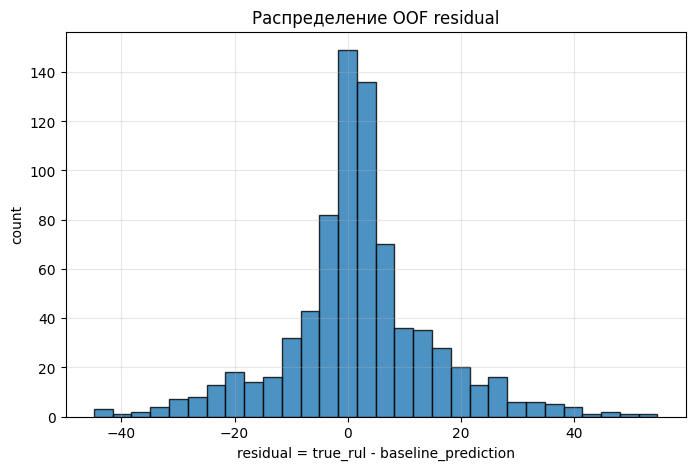

In [14]:
plt.figure(figsize=(8, 5))
plt.hist(oof_calibration_df["residual"], bins=30, edgecolor="black", alpha=0.8)
plt.xlabel("residual = true_rul - baseline_prediction")
plt.ylabel("count")
plt.title("Распределение OOF residual")
plt.grid(True, alpha=0.3)
plt.show()

In [15]:
calibration_feature_columns = [
    "baseline_prediction",
    "mean_prediction",
    "q20",
    "q35",
    "q50",
    "q80",
    "tree_std",
    "tree_iqr",
    "mean_minus_q35",
    "q80_minus_q35",
    "q35_minus_q20",
    "predicted_near_flag",
    "predicted_warning_flag",
    "predicted_long_flag",
]

oof_units = np.array(sorted(oof_calibration_df["unit_id"].unique()))
train_units_internal, valid_units_internal = train_test_split(
    oof_units, test_size=0.25, random_state=RANDOM_STATE
)
oof_train_internal = oof_calibration_df[
    oof_calibration_df["unit_id"].isin(train_units_internal)
].copy()
oof_valid_internal = oof_calibration_df[
    oof_calibration_df["unit_id"].isin(valid_units_internal)
].copy()

internal_rows = []
for model_name, factory in correction_model_factories().items():
    model = factory()
    model.fit(
        oof_train_internal[calibration_feature_columns], oof_train_internal["residual"]
    )
    pred_residual_valid = model.predict(oof_valid_internal[calibration_feature_columns])
    corrected_valid = np.maximum(
        oof_valid_internal["baseline_prediction"].to_numpy() + pred_residual_valid, 0
    )
    metrics = metrics_from_error_extended(
        build_error_table(
            oof_valid_internal["true_rul"],
            corrected_valid,
            model_name,
            oof_valid_internal["unit_id"],
        )
    )
    internal_rows.append({"correction_model_name": model_name, **metrics})

internal_correction_eval_df = pd.DataFrame(internal_rows).sort_values(
    ["MAE", "asymmetric_RUL_score"]
)
internal_correction_eval_df[
    [
        "correction_model_name",
        "MAE",
        "RMSE",
        "R2",
        "asymmetric_RUL_score",
        "mean_error",
        "overestimation_share",
        "max_overestimation",
        "near_failure_MAE",
        "warning_zone_MAE",
    ]
]

,correction_model_name,MAE,RMSE,R2,asymmetric_RUL_score,mean_error,overestimation_share,max_overestimation,near_failure_MAE,warning_zone_MAE
1,RF_depth6,8.503384,12.493470,0.897709,511.574217,0.241141,0.529101,45.297034,3.384618,10.642734
0,RF_depth4,8.560855,12.508295,0.897466,503.568083,0.263167,0.529101,43.537968,3.487805,10.529799
2,GB_huber,8.612862,12.559200,0.896630,496.024638,0.062037,0.507937,41.751167,3.484512,10.247164


In [16]:
official_calibration_features = calibration_features_from_summary(baseline_summary)
correction_results = []
trained_correction_models = {}
for model_name, factory in correction_model_factories().items():
    correction_model = factory()
    correction_model.fit(
        oof_calibration_df[calibration_feature_columns], oof_calibration_df["residual"]
    )
    trained_correction_models[model_name] = correction_model
    predicted_residual = correction_model.predict(
        official_calibration_features[calibration_feature_columns]
    )
    for correction_clip in correction_clip_grid:
        clipped_residual = np.clip(
            predicted_residual, -correction_clip, correction_clip
        )
        pred_corrected = np.maximum(pred_baseline + clipped_residual, 0)
        for shift in residual_shift_grid:
            pred_final = np.maximum(pred_corrected - shift, 0)
            metrics = evaluate_prediction(
                "OOF residual correction",
                y_test_official,
                pred_final,
                official_unit_ids,
                description=model_name,
                feature_count=X_train_baseline.shape[1],
                shift=float(shift),
                extra={
                    "correction_model_name": model_name,
                    "correction_clip": correction_clip,
                },
            )
            correction_results.append(metrics)

correction_results_df = pd.DataFrame(correction_results)
correction_results_df.sort_values(["MAE", "asymmetric_RUL_score"]).head(15)[
    [
        "correction_model_name",
        "correction_clip",
        "shift",
        "MAE",
        "RMSE",
        "R2",
        "asymmetric_RUL_score",
        "mean_error",
        "overestimation_share",
        "max_overestimation",
        "near_failure_MAE",
        "warning_zone_MAE",
    ]
]

,correction_model_name,correction_clip,shift,MAE,RMSE,R2,asymmetric_RUL_score,mean_error,overestimation_share,max_overestimation,near_failure_MAE,warning_zone_MAE
32,RF_depth6,5,2.0,8.786805,12.478306,0.909832,207.044321,-2.081205,0.47,31.102603,2.321336,6.361470
31,RF_depth6,5,1.5,8.790502,12.404713,0.910893,208.105095,-1.581205,0.53,31.602603,2.314104,6.511499
30,RF_depth6,5,1.0,8.832238,12.350939,0.911663,210.112811,-1.081205,0.56,32.102603,2.421051,6.717382
39,RF_depth6,10,2.0,8.832318,12.542797,0.908898,207.768116,-2.159508,0.47,31.102603,2.321336,6.261986
33,RF_depth6,5,2.5,8.834900,12.571369,0.908482,207.038441,-2.581205,0.44,30.602603,2.486747,6.214411
38,RF_depth6,10,1.5,8.836015,12.466445,0.910003,208.872534,-1.659508,0.53,31.602603,2.314104,6.412015
46,RF_depth6,15,2.0,8.860866,12.594408,0.908146,209.192666,-2.177220,0.47,31.102603,2.321336,6.261986
53,RF_depth6,20,2.0,8.860866,12.594408,0.908146,209.192666,-2.177220,0.47,31.102603,2.321336,6.261986
45,RF_depth6,15,1.5,8.864564,12.517664,0.909262,210.258267,-1.677220,0.53,31.602603,2.314104,6.412015
52,RF_depth6,20,1.5,8.864564,12.517664,0.909262,210.258267,-1.677220,0.53,31.602603,2.314104,6.412015


In [17]:
correction_results_df.sort_values(["asymmetric_RUL_score", "MAE"]).head(15)[
    [
        "correction_model_name",
        "correction_clip",
        "shift",
        "MAE",
        "RMSE",
        "R2",
        "asymmetric_RUL_score",
        "mean_error",
        "overestimation_share",
        "max_overestimation",
        "near_failure_MAE",
        "warning_zone_MAE",
    ]
]

,correction_model_name,correction_clip,shift,MAE,RMSE,R2,asymmetric_RUL_score,mean_error,overestimation_share,max_overestimation,near_failure_MAE,warning_zone_MAE
33,RF_depth6,5,2.5,8.834900,12.571369,0.908482,207.038441,-2.581205,0.44,30.602603,2.486747,6.214411
32,RF_depth6,5,2.0,8.786805,12.478306,0.909832,207.044321,-2.081205,0.47,31.102603,2.321336,6.361470
40,RF_depth6,10,2.5,8.880413,12.638484,0.907502,207.720477,-2.659508,0.44,30.602603,2.486747,6.114927
39,RF_depth6,10,2.0,8.832318,12.542797,0.908898,207.768116,-2.159508,0.47,31.102603,2.321336,6.261986
34,RF_depth6,5,3.0,8.911229,12.683474,0.906843,207.867956,-3.081205,0.41,30.102603,2.668641,6.067352
31,RF_depth6,5,1.5,8.790502,12.404713,0.910893,208.105095,-1.581205,0.53,31.602603,2.314104,6.511499
41,RF_depth6,10,3.0,8.960241,12.753069,0.905818,208.540907,-3.159508,0.40,30.102603,2.668641,5.967868
38,RF_depth6,10,1.5,8.836015,12.466445,0.910003,208.872534,-1.659508,0.53,31.602603,2.314104,6.412015
47,RF_depth6,15,2.5,8.908962,12.690404,0.906741,209.186124,-2.677220,0.44,30.602603,2.486747,6.114927
54,RF_depth6,20,2.5,8.908962,12.690404,0.906741,209.186124,-2.677220,0.44,30.602603,2.486747,6.114927


In [18]:
balanced_correction_pool = correction_results_df[
    (correction_results_df["MAE"] <= baseline_metrics["MAE"] * 1.03)
    & (
        correction_results_df["asymmetric_RUL_score"]
        < baseline_metrics["asymmetric_RUL_score"]
    )
    & (
        correction_results_df["overestimation_share"]
        <= baseline_metrics["overestimation_share"]
    )
]
if len(balanced_correction_pool):
    best_correction = balanced_correction_pool.sort_values(
        ["MAE", "asymmetric_RUL_score"]
    ).iloc[0]
    correction_safety_condition_met = True
else:
    best_correction = correction_results_df.sort_values(
        ["MAE", "asymmetric_RUL_score"]
    ).iloc[0]
    correction_safety_condition_met = False

pd.DataFrame(
    [
        {
            **best_correction.to_dict(),
            "safety_condition_met": correction_safety_condition_met,
        }
    ]
)[
    [
        "correction_model_name",
        "correction_clip",
        "shift",
        "safety_condition_met",
        "MAE",
        "RMSE",
        "R2",
        "asymmetric_RUL_score",
        "mean_error",
        "overestimation_share",
        "max_overestimation",
        "near_failure_MAE",
        "warning_zone_MAE",
    ]
]

,correction_model_name,correction_clip,shift,safety_condition_met,MAE,RMSE,R2,asymmetric_RUL_score,mean_error,overestimation_share,max_overestimation,near_failure_MAE,warning_zone_MAE
0,RF_depth6,5,2.0,True,8.786805,12.478306,0.909832,207.044321,-2.081205,0.47,31.102603,2.321336,6.36147


### 7.4. Модель с onset features

In [19]:
onset_variant_specs = [
    {
        "method": "baseline_without_onset",
        "onset_variant": "none",
        "threshold_sensor_count": np.nan,
    },
    {
        "method": "normalized_deviation_summary",
        "onset_variant": "deviation_summary",
        "threshold_sensor_count": np.nan,
    },
]
for threshold_sensor_count in onset_threshold_grid:
    onset_variant_specs.append(
        {
            "method": f"deviation_summary_onset_threshold_{threshold_sensor_count}",
            "onset_variant": "deviation_summary_onset",
            "threshold_sensor_count": threshold_sensor_count,
        }
    )

onset_results = []
onset_models = {}
onset_test_predictions = {}
onset_feature_matrices = {}
for spec in onset_variant_specs:
    onset_variant = spec["onset_variant"]
    threshold_value = (
        3
        if pd.isna(spec["threshold_sensor_count"])
        else int(spec["threshold_sensor_count"])
    )
    X_train_onset, y_train_onset_raw = build_model_features(
        train_df,
        baseline_candidate,
        "train",
        onset_variant=onset_variant,
        threshold_sensor_count=threshold_value,
        cap_target=False,
    )
    X_test_onset, onset_unit_ids = build_model_features(
        test_df,
        baseline_candidate,
        "official_test",
        onset_variant=onset_variant,
        threshold_sensor_count=threshold_value,
    )
    y_train_onset = y_train_onset_raw.clip(upper=BASELINE_CAP)
    onset_model = train_rf_model_for_features(
        X_train_onset, y_train_onset, baseline_candidate
    )
    onset_tree_predictions = np.array(
        [tree.predict(X_test_onset) for tree in onset_model.estimators_]
    )
    onset_summary = tree_prediction_summary(onset_tree_predictions)
    onset_pred = onset_summary["baseline_prediction"].to_numpy()
    onset_metrics = evaluate_prediction(
        spec["method"],
        y_test_official,
        onset_pred,
        onset_unit_ids,
        description=onset_variant,
        feature_count=X_train_onset.shape[1],
        shift=BASELINE_SHIFT,
        extra={"threshold_sensor_count": spec["threshold_sensor_count"]},
    )
    onset_results.append(onset_metrics)
    onset_models[spec["method"]] = onset_model
    onset_test_predictions[spec["method"]] = {
        "prediction": onset_pred,
        "summary": onset_summary,
        "X_train": X_train_onset,
        "X_test": X_test_onset,
        "unit_ids": onset_unit_ids,
        "onset_variant": onset_variant,
        "threshold_sensor_count": threshold_value,
    }
    onset_feature_matrices[spec["method"]] = X_train_onset

onset_results_df = pd.DataFrame(onset_results)
best_onset = onset_results_df.sort_values(["MAE", "asymmetric_RUL_score"]).iloc[0]
onset_improved = bool(
    (onset_results_df["MAE"] < baseline_metrics["MAE"]).any()
    or (
        onset_results_df["asymmetric_RUL_score"]
        < baseline_metrics["asymmetric_RUL_score"]
    ).any()
)
onset_results_df[
    [
        "method",
        "description",
        "threshold_sensor_count",
        "feature_count",
        "MAE",
        "RMSE",
        "R2",
        "asymmetric_RUL_score",
        "mean_error",
        "overestimation_share",
        "max_overestimation",
        "near_failure_MAE",
        "warning_zone_MAE",
    ]
]

/Users/lev/Library/Python/3.9/lib/python/site-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but DecisionTreeRegressor was fitted without feature names
  warnings.warn(
/Users/lev/Library/Python/3.9/lib/python/site-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but DecisionTreeRegressor was fitted without feature names
  warnings.warn(
/Users/lev/Library/Python/3.9/lib/python/site-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but DecisionTreeRegressor was fitted without feature names
  warnings.warn(
/Users/lev/Library/Python/3.9/lib/python/site-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but DecisionTreeRegressor was fitted without feature names
  warnings.warn(
/Users/lev/Library/Python/3.9/lib/python/site-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but DecisionTreeRegressor was fitted without feature names
  warnings.warn(
/User

,method,description,threshold_sensor_count,feature_count,MAE,RMSE,R2,asymmetric_RUL_score,mean_error,overestimation_share,max_overestimation,near_failure_MAE,warning_zone_MAE
0,baseline_without_onset,none,NaN,384,8.922427,12.761892,0.905687,231.970144,-1.333776,0.47,35.036503,2.381176,6.127128
1,normalized_deviation_summary,deviation_summary,NaN,428,10.291313,15.181579,0.866533,354.569441,-2.115820,0.44,35.248629,2.697087,5.690114
2,deviation_summary_onset_threshold_2,deviation_summary_onset,2.0,430,11.295263,16.846538,0.835653,444.980218,-3.863335,0.41,39.364441,2.786132,5.493138
3,deviation_summary_onset_threshold_3,deviation_summary_onset,3.0,430,9.838355,14.553347,0.877350,325.685178,-1.864137,0.47,36.037691,2.468379,4.917139
4,deviation_summary_onset_threshold_4,deviation_summary_onset,4.0,430,9.852576,14.322128,0.881217,294.117879,-2.060410,0.44,33.136284,2.375251,5.156764


## 8. Подход C: комбинация onset features и OOF correction

In [20]:
residual_improved = bool(
    (best_correction["MAE"] < baseline_metrics["MAE"])
    or (
        best_correction["asymmetric_RUL_score"]
        < baseline_metrics["asymmetric_RUL_score"]
    )
)
combined_results = []
combined_built = False
best_combined_prediction = None
best_combined_oof_df = pd.DataFrame()

if onset_improved:
    best_onset_method = best_onset["method"]
    best_onset_info = onset_test_predictions[best_onset_method]
    combined_oof_df = build_oof_calibration_dataset(
        onset_variant=best_onset_info["onset_variant"],
        threshold_sensor_count=best_onset_info["threshold_sensor_count"],
    )
    combined_model_name = best_correction["correction_model_name"]
    combined_model = correction_model_factories()[combined_model_name]()
    combined_model.fit(
        combined_oof_df[calibration_feature_columns], combined_oof_df["residual"]
    )
    combined_official_features = calibration_features_from_summary(
        best_onset_info["summary"]
    )
    combined_predicted_residual = combined_model.predict(
        combined_official_features[calibration_feature_columns]
    )
    combined_clip = int(best_correction["correction_clip"])
    combined_clipped_residual = np.clip(
        combined_predicted_residual, -combined_clip, combined_clip
    )
    for shift in combined_shift_grid:
        pred_combined = np.maximum(
            best_onset_info["prediction"] + combined_clipped_residual - shift, 0
        )
        combined_results.append(
            evaluate_prediction(
                "combined_onset_oof_correction",
                y_test_official,
                pred_combined,
                best_onset_info["unit_ids"],
                description=f"{best_onset_method} + {combined_model_name}",
                feature_count=best_onset_info["X_train"].shape[1],
                shift=float(shift),
                extra={"correction_clip": combined_clip},
            )
        )
    combined_results_df = pd.DataFrame(combined_results)
    best_combined = combined_results_df.sort_values(
        ["MAE", "asymmetric_RUL_score"]
    ).iloc[0]
    best_combined_prediction = np.maximum(
        best_onset_info["prediction"]
        + combined_clipped_residual
        - float(best_combined["shift"]),
        0,
    )
    best_combined_oof_df = combined_oof_df.copy()
    combined_built = True
else:
    combined_results_df = pd.DataFrame(
        columns=[
            "method",
            "description",
            "MAE",
            "RMSE",
            "R2",
            "asymmetric_RUL_score",
            "mean_error",
            "overestimation_share",
            "max_overestimation",
            "near_failure_MAE",
            "warning_zone_MAE",
            "feature_count",
            "shift",
        ]
    )
    best_combined = pd.Series(dtype=object)

combined_results_df

,method,description,MAE,RMSE,R2,asymmetric_RUL_score,mean_error,overestimation_share,max_overestimation,near_failure_MAE,warning_zone_MAE,feature_count,shift


## 9. Итоговая таблица сравнения

In [21]:
comparison_rows = []
comparison_rows.append(
    {
        "method": "Week 5 baseline",
        "description": "quantile ensemble, cap=140, q35/mean, shift=1.0",
        "feature_count": X_train_baseline.shape[1],
        "shift": BASELINE_SHIFT,
        **baseline_metrics,
    }
)
comparison_rows.append(
    {
        "method": "Best OOF residual correction",
        "description": f"{best_correction['correction_model_name']}, clip={best_correction['correction_clip']}",
        "feature_count": X_train_baseline.shape[1],
        "shift": best_correction["shift"],
        **{
            key: best_correction[key]
            for key in [
                "MAE",
                "RMSE",
                "R2",
                "asymmetric_RUL_score",
                "mean_error",
                "overestimation_share",
                "max_overestimation",
                "near_failure_MAE",
                "warning_zone_MAE",
            ]
        },
    }
)
comparison_rows.append(
    {
        "method": "Best degradation-onset model",
        "description": best_onset["description"],
        "feature_count": best_onset["feature_count"],
        "shift": best_onset["shift"],
        **{
            key: best_onset[key]
            for key in [
                "MAE",
                "RMSE",
                "R2",
                "asymmetric_RUL_score",
                "mean_error",
                "overestimation_share",
                "max_overestimation",
                "near_failure_MAE",
                "warning_zone_MAE",
            ]
        },
    }
)
if combined_built:
    comparison_rows.append(
        {
            "method": "Best combined model",
            "description": best_combined["description"],
            "feature_count": best_combined["feature_count"],
            "shift": best_combined["shift"],
            **{
                key: best_combined[key]
                for key in [
                    "MAE",
                    "RMSE",
                    "R2",
                    "asymmetric_RUL_score",
                    "mean_error",
                    "overestimation_share",
                    "max_overestimation",
                    "near_failure_MAE",
                    "warning_zone_MAE",
                ]
            },
        }
    )

final_comparison_df = (
    pd.DataFrame(comparison_rows).sort_values("MAE").reset_index(drop=True)
)
final_comparison_df[
    [
        "method",
        "description",
        "MAE",
        "RMSE",
        "R2",
        "asymmetric_RUL_score",
        "mean_error",
        "overestimation_share",
        "max_overestimation",
        "near_failure_MAE",
        "warning_zone_MAE",
        "feature_count",
        "shift",
    ]
]

,method,description,MAE,RMSE,R2,asymmetric_RUL_score,mean_error,overestimation_share,max_overestimation,near_failure_MAE,warning_zone_MAE,feature_count,shift
0,Best OOF residual correction,"RF_depth6, clip=5",8.786805,12.478306,0.909832,207.044321,-2.081205,0.47,31.102603,2.321336,6.361470,384,2.0
1,Week 5 baseline,"quantile ensemble, cap=140, q35/mean, shift=1.0",8.922427,12.761892,0.905687,231.970144,-1.333776,0.47,35.036503,2.381176,6.127128,384,1.0
2,Best degradation-onset model,none,8.922427,12.761892,0.905687,231.970144,-1.333776,0.47,35.036503,2.381176,6.127128,384,1.0


In [22]:
best_by_MAE = final_comparison_df.sort_values(["MAE", "asymmetric_RUL_score"]).iloc[0]
best_by_asymmetric_RUL_score = final_comparison_df.sort_values(
    ["asymmetric_RUL_score", "MAE"]
).iloc[0]
safety_pool = final_comparison_df[
    final_comparison_df["MAE"] <= baseline_metrics["MAE"] * 1.03
]
if len(safety_pool):
    best_safety_balanced = safety_pool.sort_values(
        ["overestimation_share", "max_overestimation", "asymmetric_RUL_score", "MAE"]
    ).iloc[0]
else:
    best_safety_balanced = final_comparison_df.sort_values(
        ["overestimation_share", "max_overestimation", "asymmetric_RUL_score", "MAE"]
    ).iloc[0]

comparison_summary_df = pd.DataFrame(
    [
        {"summary": "best_by_MAE", **best_by_MAE.to_dict()},
        {
            "summary": "best_by_asymmetric_RUL_score",
            **best_by_asymmetric_RUL_score.to_dict(),
        },
        {"summary": "best_safety_balanced", **best_safety_balanced.to_dict()},
        {
            "summary": "achieved_MAE_below_8_9",
            "method": bool((final_comparison_df["MAE"] < 8.9).any()),
            "description": "",
            "MAE": final_comparison_df["MAE"].min(),
        },
        {
            "summary": "achieved_MAE_below_8_5",
            "method": bool((final_comparison_df["MAE"] < 8.5).any()),
            "description": "",
            "MAE": final_comparison_df["MAE"].min(),
        },
    ]
)
comparison_summary_df

,summary,method,description,feature_count,shift,MAE,RMSE,R2,mean_error,overestimation_count,overestimation_share,mean_overestimation,max_overestimation,near_failure_MAE,warning_zone_MAE,asymmetric_RUL_score,mean_asymmetric_score,overestimation_component,underestimation_component
0,best_by_MAE,Best OOF residual correction,"RF_depth6, clip=5",384.0,2.0,8.786805,12.478306,0.909832,-2.081205,NaN,0.47,NaN,31.102603,2.321336,6.36147,207.044321,NaN,NaN,NaN
1,best_by_asymmetric_RUL_score,Best OOF residual correction,"RF_depth6, clip=5",384.0,2.0,8.786805,12.478306,0.909832,-2.081205,NaN,0.47,NaN,31.102603,2.321336,6.36147,207.044321,NaN,NaN,NaN
2,best_safety_balanced,Best OOF residual correction,"RF_depth6, clip=5",384.0,2.0,8.786805,12.478306,0.909832,-2.081205,NaN,0.47,NaN,31.102603,2.321336,6.36147,207.044321,NaN,NaN,NaN
3,achieved_MAE_below_8_9,True,,NaN,NaN,8.786805,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,achieved_MAE_below_8_5,False,,NaN,NaN,8.786805,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## 10. Графики

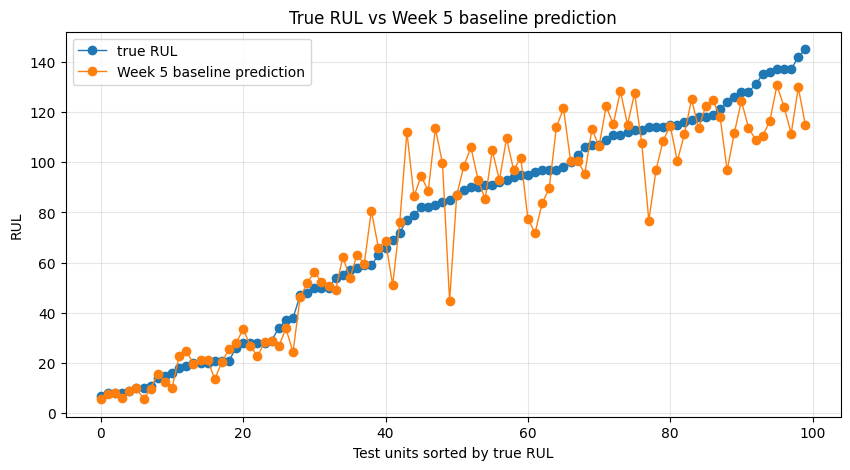

In [23]:
best_new_row = (
    final_comparison_df[final_comparison_df["method"] != "Week 5 baseline"]
    .sort_values(["MAE", "asymmetric_RUL_score"])
    .head(1)
)
if len(best_new_row):
    best_new_method = best_new_row.iloc[0]["method"]
else:
    best_new_method = "Week 5 baseline"

if best_new_method == "Best OOF residual correction":
    best_correction_model = trained_correction_models[
        best_correction["correction_model_name"]
    ]
    best_predicted_residual = best_correction_model.predict(
        official_calibration_features[calibration_feature_columns]
    )
    best_new_prediction = np.maximum(
        pred_baseline
        + np.clip(
            best_predicted_residual,
            -best_correction["correction_clip"],
            best_correction["correction_clip"],
        )
        - best_correction["shift"],
        0,
    )
elif best_new_method == "Best degradation-onset model":
    best_new_prediction = onset_test_predictions[best_onset["method"]]["prediction"]
elif best_new_method == "Best combined model" and combined_built:
    best_new_prediction = best_combined_prediction
else:
    best_new_prediction = pred_baseline

order = np.argsort(np.asarray(y_test_official))
plt.figure(figsize=(10, 5))
plt.plot(np.asarray(y_test_official)[order], label="true RUL", marker="o", linewidth=1)
plt.plot(
    pred_baseline[order], label="Week 5 baseline prediction", marker="o", linewidth=1
)
plt.xlabel("Test units sorted by true RUL")
plt.ylabel("RUL")
plt.title("True RUL vs Week 5 baseline prediction")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

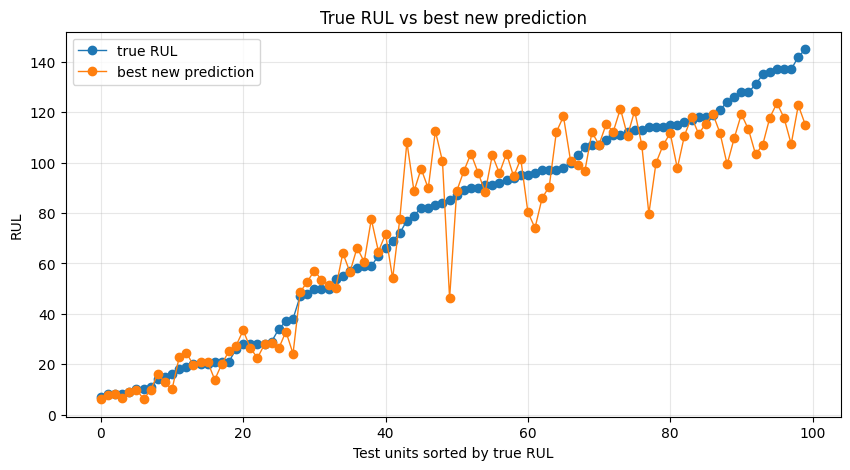

In [24]:
plt.figure(figsize=(10, 5))
plt.plot(np.asarray(y_test_official)[order], label="true RUL", marker="o", linewidth=1)
plt.plot(
    best_new_prediction[order], label="best new prediction", marker="o", linewidth=1
)
plt.xlabel("Test units sorted by true RUL")
plt.ylabel("RUL")
plt.title("True RUL vs best new prediction")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

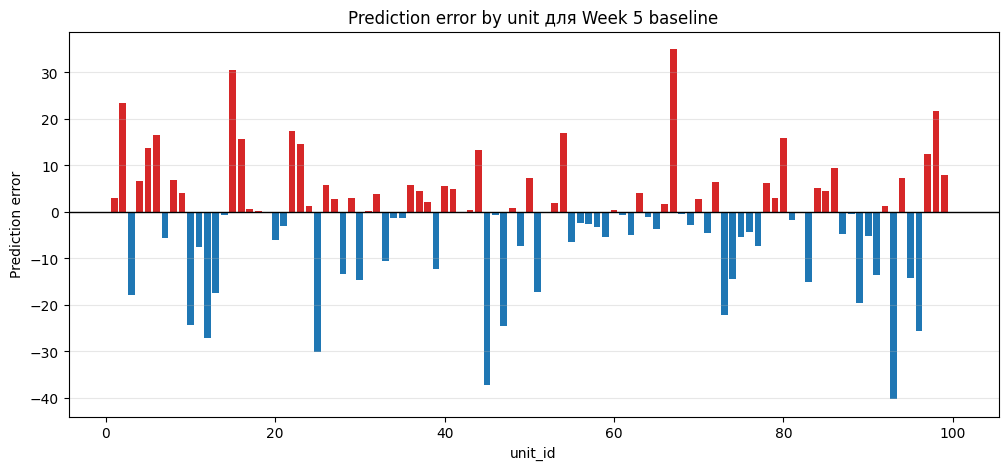

In [25]:
plt.figure(figsize=(12, 5))
colors = np.where(baseline_error_df["error"] > 0, "tab:red", "tab:blue")
plt.bar(baseline_error_df["id"], baseline_error_df["error"], color=colors)
plt.axhline(0, color="black", linewidth=1)
plt.xlabel("unit_id")
plt.ylabel("Prediction error")
plt.title("Prediction error by unit для Week 5 baseline")
plt.grid(True, axis="y", alpha=0.3)
plt.show()

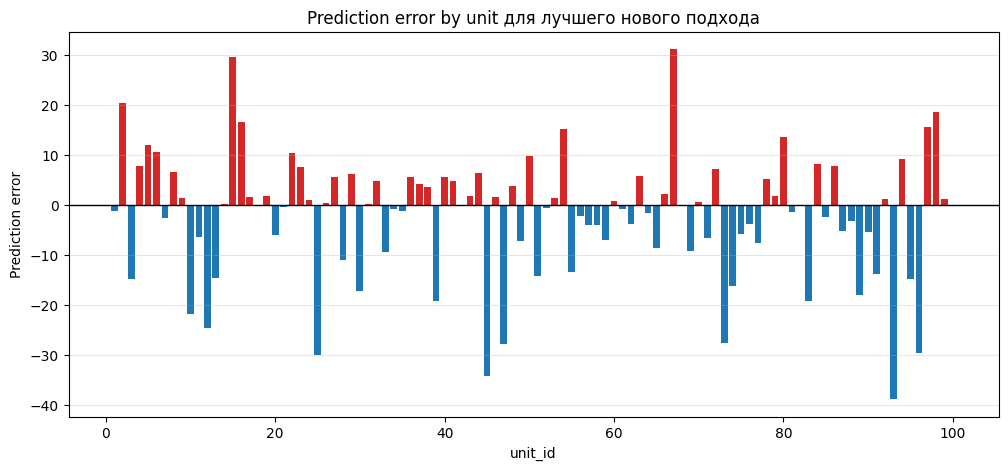

In [26]:
best_new_error_df = build_error_table(
    y_test_official, best_new_prediction, "best new", official_unit_ids
)
plt.figure(figsize=(12, 5))
colors = np.where(best_new_error_df["error"] > 0, "tab:red", "tab:blue")
plt.bar(best_new_error_df["id"], best_new_error_df["error"], color=colors)
plt.axhline(0, color="black", linewidth=1)
plt.xlabel("unit_id")
plt.ylabel("Prediction error")
plt.title("Prediction error by unit для лучшего нового подхода")
plt.grid(True, axis="y", alpha=0.3)
plt.show()

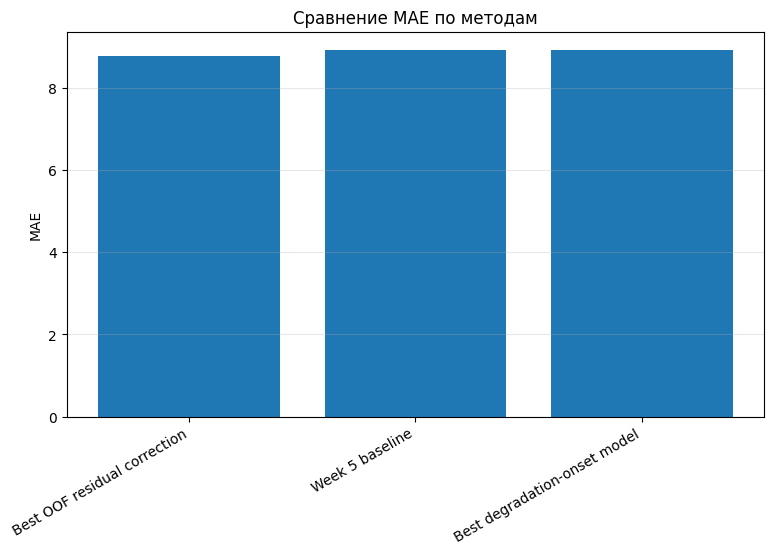

In [27]:
plt.figure(figsize=(9, 5))
plt.bar(final_comparison_df["method"], final_comparison_df["MAE"])
plt.xticks(rotation=30, ha="right")
plt.ylabel("MAE")
plt.title("Сравнение MAE по методам")
plt.grid(True, axis="y", alpha=0.3)
plt.show()

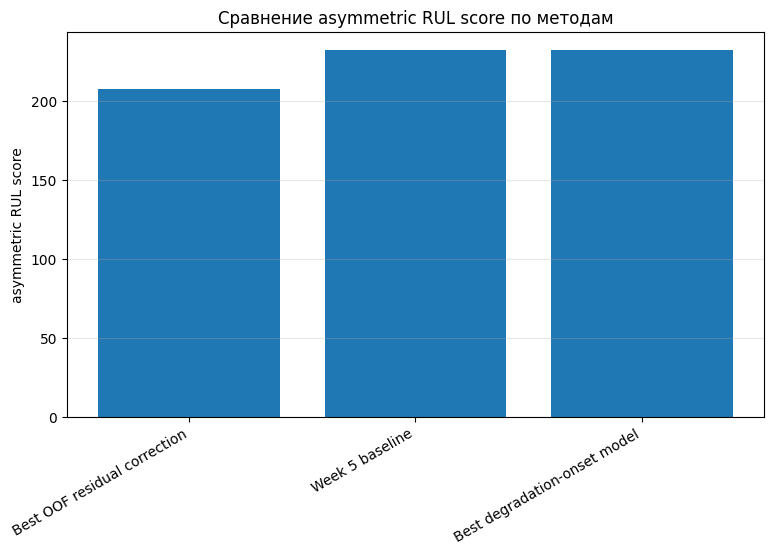

In [28]:
plt.figure(figsize=(9, 5))
plt.bar(final_comparison_df["method"], final_comparison_df["asymmetric_RUL_score"])
plt.xticks(rotation=30, ha="right")
plt.ylabel("asymmetric RUL score")
plt.title("Сравнение asymmetric RUL score по методам")
plt.grid(True, axis="y", alpha=0.3)
plt.show()

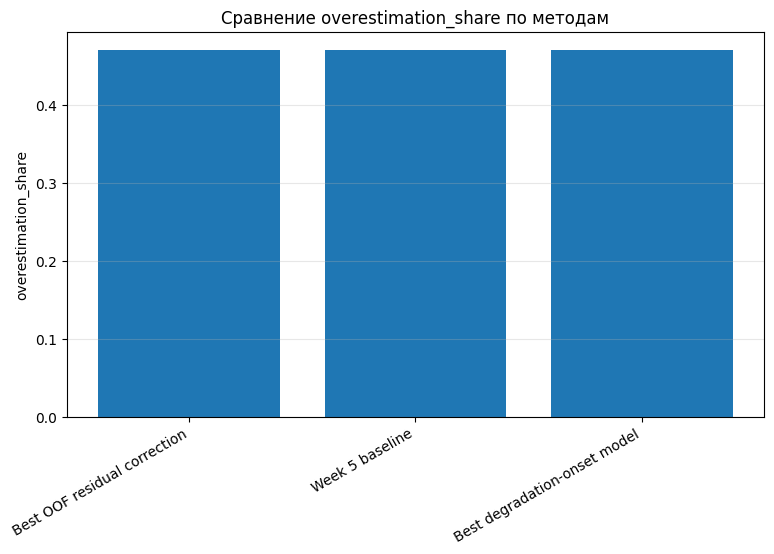

In [29]:
plt.figure(figsize=(9, 5))
plt.bar(final_comparison_df["method"], final_comparison_df["overestimation_share"])
plt.xticks(rotation=30, ha="right")
plt.ylabel("overestimation_share")
plt.title("Сравнение overestimation_share по методам")
plt.grid(True, axis="y", alpha=0.3)
plt.show()

In [30]:
if onset_improved:
    best_onset_info = onset_test_predictions[best_onset["method"]]
    if best_onset_info["onset_variant"] == "deviation_summary_onset":
        onset_test_features = build_onset_features_for_units(
            test_df,
            baseline_candidate,
            "official_test",
            onset_variant="deviation_summary_onset",
            threshold_sensor_count=best_onset_info["threshold_sensor_count"],
        )
        plt.figure(figsize=(8, 5))
        plt.hist(
            onset_test_features["cycles_since_degradation_onset"],
            bins=20,
            edgecolor="black",
            alpha=0.8,
        )
        plt.xlabel("cycles_since_degradation_onset")
        plt.ylabel("count")
        plt.title("Распределение cycles_since_degradation_onset")
        plt.grid(True, alpha=0.3)
        plt.show()
        plt.figure(figsize=(8, 5))
        plt.scatter(
            onset_test_features["cycles_since_degradation_onset"],
            y_test_official,
            alpha=0.8,
        )
        plt.xlabel("cycles_since_degradation_onset")
        plt.ylabel("true RUL")
        plt.title("cycles_since_degradation_onset vs true RUL")
        plt.grid(True, alpha=0.3)
        plt.show()

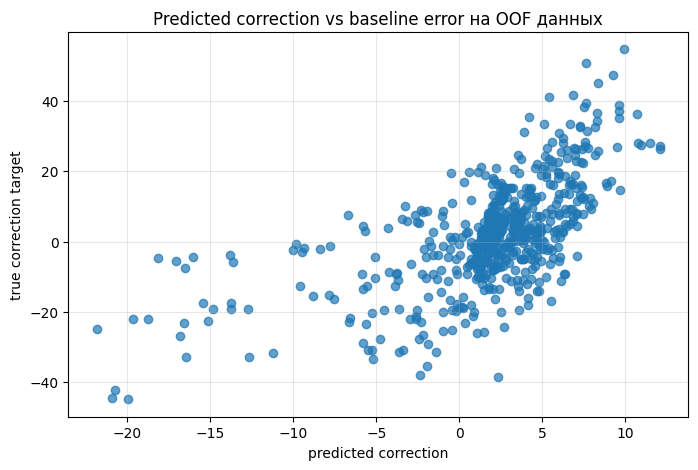

In [31]:
if len(oof_calibration_df):
    best_model_for_oof_plot = trained_correction_models[
        best_correction["correction_model_name"]
    ]
    predicted_oof_correction = best_model_for_oof_plot.predict(
        oof_calibration_df[calibration_feature_columns]
    )
    plt.figure(figsize=(8, 5))
    plt.scatter(
        predicted_oof_correction, -oof_calibration_df["baseline_error"], alpha=0.7
    )
    plt.xlabel("predicted correction")
    plt.ylabel("true correction target")
    plt.title("Predicted correction vs baseline error на OOF данных")
    plt.grid(True, alpha=0.3)
    plt.show()

## 11. Финальные выводы

In [32]:
baseline_mae = baseline_metrics["MAE"]
baseline_score = baseline_metrics["asymmetric_RUL_score"]
correction_improved_final = bool(
    (best_correction["MAE"] < baseline_mae)
    or (best_correction["asymmetric_RUL_score"] < baseline_score)
)
onset_improved_final = bool(
    (best_onset["MAE"] < baseline_mae)
    or (best_onset["asymmetric_RUL_score"] < baseline_score)
)
combined_best_final = bool(
    combined_built and best_by_MAE["method"] == "Best combined model"
)

lines = []
if correction_improved_final:
    lines.append(
        "OOF residual correction улучшила baseline: фиксированная квантильная формула была дополнена обучаемой коррекцией, построенной без использования official test для обучения."
    )
if onset_improved_final:
    lines.append(
        "Degradation-onset features улучшили baseline: признаки момента начала деградации перенесли идею поиска важного участка временного ряда в классический RandomForest pipeline."
    )
if combined_best_final:
    lines.append(
        "Лучший результат получен за счёт комбинации признаков начала деградации и обучаемой коррекции неопределённости."
    )
if (
    not correction_improved_final
    and not onset_improved_final
    and not combined_best_final
):
    lines.append(
        "Week 5 baseline с MAE около 8.92 остаётся лучшим: дополнительные адаптивные коррекции и onset features не дали устойчивого прироста."
    )
lines.append(
    "На этой неделе мы не выполняли новый широкий перебор по official test. Основные обучаемые корректирующие решения формировались через out-of-fold predictions внутри train-выборки. Official test использовался для финального сравнения уже готовых вариантов."
)

display(Markdown("\n\n".join(lines)))

OOF residual correction улучшила baseline: фиксированная квантильная формула была дополнена обучаемой коррекцией, построенной без использования official test для обучения.

На этой неделе мы не выполняли новый широкий перебор по official test. Основные обучаемые корректирующие решения формировались через out-of-fold predictions внутри train-выборки. Official test использовался для финального сравнения уже готовых вариантов.

## 12. Ограничения эксперимента

Notebook проверяет только safety-oriented расширения текущего Week 5 pipeline: asymmetric score, out-of-fold residual calibration, degradation-onset признаки и их ограниченную комбинацию.